In [58]:
import pandas as pd
import json
import numpy as np
from sklearn.impute import KNNImputer

from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import RobustScaler

import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import root_mean_squared_error, r2_score, mean_absolute_error, mean_absolute_percentage_error
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor


df = pd.read_table(r"final.csv", sep=";")
df = df.drop_duplicates()



In [59]:
df.info()
df.head()

<class 'pandas.DataFrame'>
Index: 55152 entries, 0 to 61677
Data columns (total 28 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   accommodation_type    55152 non-null  str    
 1   author                54079 non-null  str    
 2   author_type           54079 non-null  str    
 3   deal_type             55152 non-null  str    
 4   description           55152 non-null  str    
 5   district              41736 non-null  str    
 6   finish_type           55152 non-null  str    
 7   floor                 55152 non-null  int64  
 8   floors_count          55152 non-null  int64  
 9   heating_type          55152 non-null  int64  
 10  house_material_type   55152 non-null  str    
 11  house_number          48252 non-null  str    
 12  kitchen_meters        55152 non-null  str    
 13  living_meters         55152 non-null  str    
 14  location              55152 non-null  str    
 15  metro_distance        55152 non-nul

,accommodation_type,author,author_type,deal_type,description,district,finish_type,floor,floors_count,heating_type,...,phone,price,residential_complex,rooms_count,street,total_meters,transport_score,underground,url,year_of_construction
0,flat,Центр Инвест,real_estate_agent,sale,О ПРОЕКТЕ:\n\nWill Towers — жилой комплекс биз...,Раменки,Без отделки,35,56,-1,...,7.923071e+10,28127104,Will Towers,2,проспект Генерала Дорохова,51.3,5.2,Минская,https://www.cian.ru/sale/flat/320392576/?mlSea...,2024
1,flat,Apple Real Estate,real_estate_agent,sale,Лот 1000259. Виктория Шевцова.\n\nРады предлож...,Раменки,-1,9,19,-1,...,7.915314e+10,41500000,Золотые Ключи 2,2,Минская,67.0,-1.0,Минская,https://www.cian.ru/sale/flat/326688167/?mlSea...,2004
2,flat,ID 119690304,homeowner,sale,УСЛУГИ ПРОСЬБА НЕ ПРЕДЛАГАТЬ !!! \nПродает соб...,Филевский парк,-1,7,8,-1,...,7.916816e+10,17850000,NaN,2,Василисы Кожиной,40.0,-1.0,Минская,https://www.cian.ru/sale/flat/322956324/?mlSea...,1960
3,flat,Центр Инвест,real_estate_agent,sale,О ПРОЕКТЕ:\n\nWill Towers — жилой комплекс биз...,Раменки,Без отделки,33,56,-1,...,7.923071e+10,38320818,Will Towers,2,проспект Генерала Дорохова,73.4,5.2,Минская,https://www.cian.ru/sale/flat/320392568/?mlSea...,2024
4,flat,Whitewill,real_estate_agent,sale,Квартира с двумя спальнями в комплексе премиум...,Раменки,Чистовая,23,40,-1,...,7.985722e+10,51000000,Нова ЖК,2,NaN,54.0,-1.0,Минская,https://www.cian.ru/sale/flat/327116733/?mlSea...,2027


In [60]:
df.drop(columns=['author', 'author_type', 'description', 'house_number', 'nearest_metro', 'phone', 'residential_complex', 'street', 'underground', 'url'], inplace=True)
df.head()

,accommodation_type,deal_type,district,finish_type,floor,floors_count,heating_type,house_material_type,kitchen_meters,living_meters,location,metro_distance,object_type,price,rooms_count,total_meters,transport_score,year_of_construction
0,flat,sale,Раменки,Без отделки,35,56,-1,Монолитный,6 м²,"33,3 м²",Москва,19,-1,28127104,2,51.3,5.2,2024
1,flat,sale,Раменки,-1,9,19,-1,-1,18 м²,20 м²,Москва,16,-1,41500000,2,67.0,-1.0,2004
2,flat,sale,Филевский парк,-1,7,8,-1,-1,15 м²,20 м²,Москва,11,-1,17850000,2,40.0,-1.0,1960
3,flat,sale,Раменки,Без отделки,33,56,-1,Монолитный,"6,1 м²","44,8 м²",Москва,19,-1,38320818,2,73.4,5.2,2024
4,flat,sale,Раменки,Чистовая,23,40,-1,-1,-1,49 м²,Москва,15,-1,51000000,2,54.0,-1.0,2027


In [61]:
columns = ['accommodation_type', 'deal_type', 'finish_type', 'heating_type', 'house_material_type', 'location', 'object_type']
for i in columns:
	print(df[i].value_counts())

accommodation_type
flat    55152
Name: count, dtype: int64
deal_type
sale    55152
Name: count, dtype: int64
finish_type
-1                                                         40266
Без отделки                                                 5430
Без отделки, предчистовая                                   2505
Без отделки, предчистовая, чистовая                         1942
Чистовая                                                    1908
Без отделки, чистовая                                        964
Предчистовая                                                 458
Без отделки, предчистовая, черновая, чистовая                356
Предчистовая, чистовая                                       250
Без отделки, предчистовая, черновая                          235
-                                                            235
Без отделки, чистовая с мебелью                              106
Без отделки, чистовая, чистовая с мебелью                    104
Без отделки, предчистовая, чистова

In [62]:
df.drop(columns=['accommodation_type', 'deal_type', 'finish_type', 'heating_type', 'house_material_type', 'location', 'object_type'], inplace=True)
df.head()

,district,floor,floors_count,kitchen_meters,living_meters,metro_distance,price,rooms_count,total_meters,transport_score,year_of_construction
0,Раменки,35,56,6 м²,"33,3 м²",19,28127104,2,51.3,5.2,2024
1,Раменки,9,19,18 м²,20 м²,16,41500000,2,67.0,-1.0,2004
2,Филевский парк,7,8,15 м²,20 м²,11,17850000,2,40.0,-1.0,1960
3,Раменки,33,56,"6,1 м²","44,8 м²",19,38320818,2,73.4,5.2,2024
4,Раменки,23,40,-1,49 м²,15,51000000,2,54.0,-1.0,2027


In [63]:
print(df.shape)
for i in df.columns:
    print(df[i].value_counts())
    print("Nan")
    print(df[i].isna().sum())
    print("_____________________")

(55152, 11)
district
Пресненский                                                                                                                                                   2692
Раменки                                                                                                                                                       1796
Тверской                                                                                                                                                      1781
Даниловский                                                                                                                                                   1231
Хамовники                                                                                                                                                     1217
                                                                                                                                                              ... 
в

In [64]:
df.drop(columns=["transport_score"], inplace=True)


df["district"] = df["district"].map(lambda x: x if pd.isna(x) else x.lower())

with open("county_district.json", 'r', encoding='utf-8') as file:
    districts = json.load(file)
new_districts = dict()
for i in districts:
    name = i['name'].lower()
    district_id = i['id']
    new_districts[name] = district_id
df['district'] = df['district'].replace(new_districts)
df['district'] = pd.to_numeric(df['district'], errors='coerce') #TODO INT
df = df.dropna(subset=['district'])
df['district'].value_counts()


df["kitchen_meters"] = df["kitchen_meters"].map(lambda x: x if x == -1 else float(x.split()[0].replace(',', '.')))
df["kitchen_meters"] = df["kitchen_meters"].astype("float64")
df["kitchen_meters"] = df["kitchen_meters"].map(lambda x: np.nan if x == -1.0 else x)

df["living_meters"] = df["living_meters"].map(lambda x: x if x == -1 else float(x.split()[0].replace(',', '.')))
df["living_meters"] = df["living_meters"].astype("float64")
df["living_meters"] = df["living_meters"].map(lambda x: np.nan if x == -1.0 else x)


df["rooms_count"] = df["rooms_count"].map(lambda x: np.nan if x == -1 else x)
df = df.dropna(subset=['rooms_count'])

df["total_meters"] = df["total_meters"].astype("float64")
df["total_meters"] = df["total_meters"].map(lambda x: np.nan if x == -1.0 else x)
df = df.dropna(subset=['total_meters'])


df["kitchen_meters"] = pd.to_numeric(df["kitchen_meters"], errors="coerce")

df['year_of_construction'] = pd.to_numeric(df['year_of_construction'], errors='coerce')
df["year_of_construction"] = df["year_of_construction"].replace(-1, np.nan)



In [65]:
print(df.shape)
for i in df.columns:
    print(df[i].value_counts())
    print("_____________________")
df = df.replace([-1, -1.0], np.nan)

(38869, 10)
district
61.0     2683
51.0     1785
63.0     1775
97.0     1229
64.0     1199
         ... 
43.0       11
124.0      10
70.0        5
111.0       2
146.0       1
Name: count, Length: 126, dtype: int64
_____________________
floor
2     4080
3     3588
4     3312
5     3216
6     2368
      ... 
77       2
64       2
70       1
69       1
74       1
Name: count, Length: 79, dtype: int64
_____________________
floors_count
9     3698
12    2578
17    2410
5     2366
14    2047
      ... 
97       3
60       2
80       1
83       1
95       1
Name: count, Length: 81, dtype: int64
_____________________
kitchen_meters
10.0    2526
6.0     2036
8.0     1387
9.0     1386
15.0    1219
        ... 
63.3       1
52.5       1
54.2       1
84.9       1
50.4       1
Name: count, Length: 565, dtype: int64
_____________________
living_meters
20.0     907
19.0     717
18.0     716
30.0     480
45.0     449
        ... 
109.4      1
68.8       1
110.9      1
108.2      1
91.2       1
Name: c

In [66]:
df = pd.get_dummies(df, columns=["district"])

In [67]:
y = df['price']
df.drop(columns=['price'], inplace=True)
X = df
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

In [68]:
scaler = RobustScaler()

cols_to_scale = ['kitchen_meters', 'living_meters', 'total_meters',
                 'year_of_construction', 'floor', 'floors_count',
                 'metro_distance', 'rooms_count']

X_train_scaled = X_train.copy()
X_train_scaled[cols_to_scale] = scaler.fit_transform(X_train[cols_to_scale])


X_test_scaled = X_test.copy()
X_test_scaled[cols_to_scale] = scaler.transform(X_test[cols_to_scale])

In [ ]:
imputer = KNNImputer().set_output(transform="pandas")
X_train_imputed = imputer.fit_transform(X_train_scaled)
X_test_imputed = imputer.transform(X_test_scaled)

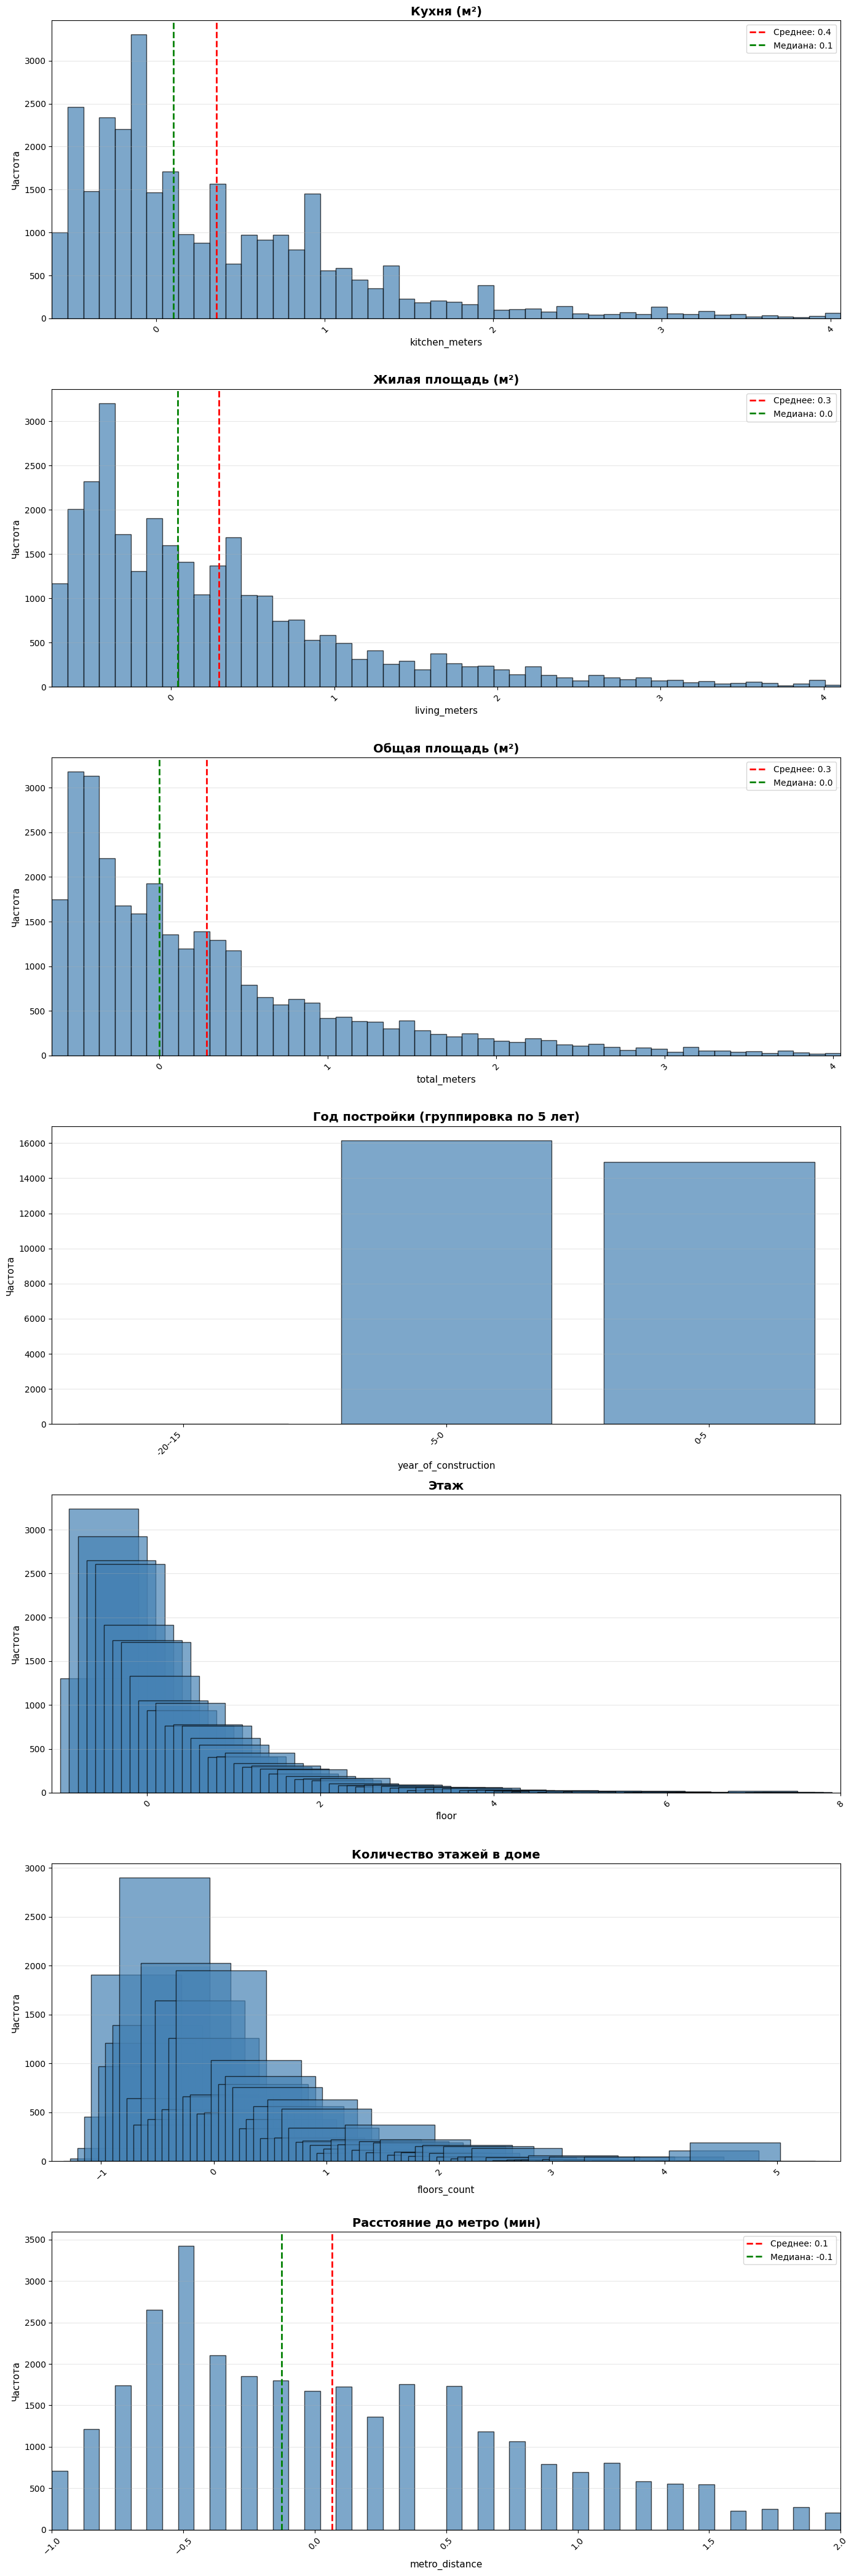

In [51]:
def visual(df):
    plots_config = {
        'kitchen_meters': {'type': 'continuous', 'xlim': None, 'title': 'Кухня (м²)'},
        'living_meters': {'type': 'continuous', 'xlim': None, 'title': 'Жилая площадь (м²)'},
        'total_meters': {'type': 'continuous', 'xlim': None, 'title': 'Общая площадь (м²)'},
        'year_of_construction': {'type': 'grouped_years', 'bin_years': 5, 'title': 'Год постройки (группировка по 5 лет)'},
        'floor': {'type': 'discrete', 'title': 'Этаж'},
        'floors_count': {'type': 'discrete', 'title': 'Количество этажей в доме'},
        'metro_distance': {'type': 'continuous', 'xlim': None, 'title': 'Расстояние до метро (мин)'},
        'price': {'type': 'continuous', 'xlim': (0, 300000000), 'title': 'Цена'}
    }

    plots_config = {col: config for col, config in plots_config.items() if col in df.columns}
    fig, axes = plt.subplots(len(plots_config), 1, figsize=(14, 6 * len(plots_config)))
    if len(plots_config) == 1:
        axes = [axes]
    for idx, (col, config) in enumerate(plots_config.items()):
        data = df[col].dropna()
        if config['type'] == 'continuous':
            lower = data.quantile(0.01)
            upper = data.quantile(0.99)


            xlim_lower = config['xlim'][0] if config['xlim'] is not None else lower
            xlim_upper = config['xlim'][1] if config['xlim'] is not None else upper


            data_filtered = data[(data >= xlim_lower) & (data <= xlim_upper)]


            axes[idx].hist(data_filtered, bins=50, edgecolor='black', alpha=0.7, color='steelblue')


            mean_val = data_filtered.mean()
            median_val = data_filtered.median()
            axes[idx].axvline(mean_val, color='red', linestyle='--', linewidth=2,
                             label=f'Среднее: {mean_val:.1f}')
            axes[idx].axvline(median_val, color='green', linestyle='--', linewidth=2,
                             label=f'Медиана: {median_val:.1f}')

            axes[idx].set_xlim(xlim_lower, xlim_upper)

        elif config['type'] == 'grouped_years':

            bin_years = config['bin_years']

            min_year = data.min()
            max_year = data.max()
            bins = np.arange(min_year - (min_year % bin_years), max_year + bin_years, bin_years)


            data_grouped = pd.cut(data, bins=bins, right=False)
            counts = data_grouped.value_counts().sort_index()


            counts = counts[counts > 0]


            labels = [f"{int(bin.left)}-{int(bin.right)}" for bin in counts.index]


            axes[idx].bar(range(len(counts)), counts.values, edgecolor='black', alpha=0.7,
                         color='steelblue', width=0.8)
            axes[idx].set_xticks(range(len(counts)))
            axes[idx].set_xticklabels(labels, rotation=45, ha='right')


            axes[idx].set_xlim(-0.5, len(counts) - 0.5)

        elif config['type'] == 'discrete':
            counts = data.value_counts().sort_index()
            axes[idx].bar(counts.index, counts.values, edgecolor='black', alpha=0.7,
                         color='steelblue', width=0.8)
            axes[idx].set_xlim(counts.index.min() - 0.5, counts.index.max() + 0.5)


        axes[idx].set_title(config['title'], fontsize=14, fontweight='bold')
        axes[idx].set_xlabel(col, fontsize=11)
        axes[idx].set_ylabel('Частота', fontsize=11)


        if config['type'] == 'continuous':
            axes[idx].legend(fontsize=10)

        axes[idx].grid(True, alpha=0.3, axis='y')


        if config['type'] == 'grouped_years':
            pass  # уже повернули
        elif config['type'] == 'discrete' and len(counts) > 15:
            axes[idx].tick_params(axis='x', rotation=45)
        elif config['type'] == 'continuous':
            axes[idx].tick_params(axis='x', rotation=45)

    plt.tight_layout()
    plt.show()






visual(X_train_imputed)

In [52]:
def remove_outliers_iqr(X, y, column, multiplier=1.5):
    Q1 = X[column].quantile(0.25)
    Q3 = X[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - multiplier * IQR
    upper_bound = Q3 + multiplier * IQR

    # Создаем маску
    mask = (X[column] >= lower_bound) & (X[column] <= upper_bound)

    # Применяем маску к X и y
    X_filtered = X[mask]
    y_filtered = y[mask]

    return X_filtered, y_filtered

In [53]:
columns = ['kitchen_meters', 'living_meters', 'total_meters', 'year_of_construction', 'metro_distance']

# Применяем для каждой колонки (последовательно)
# for c in columns:
#     X_train_imputed, y_train = remove_outliers_iqr(X_train_imputed, y_train, c, multiplier=1.5)

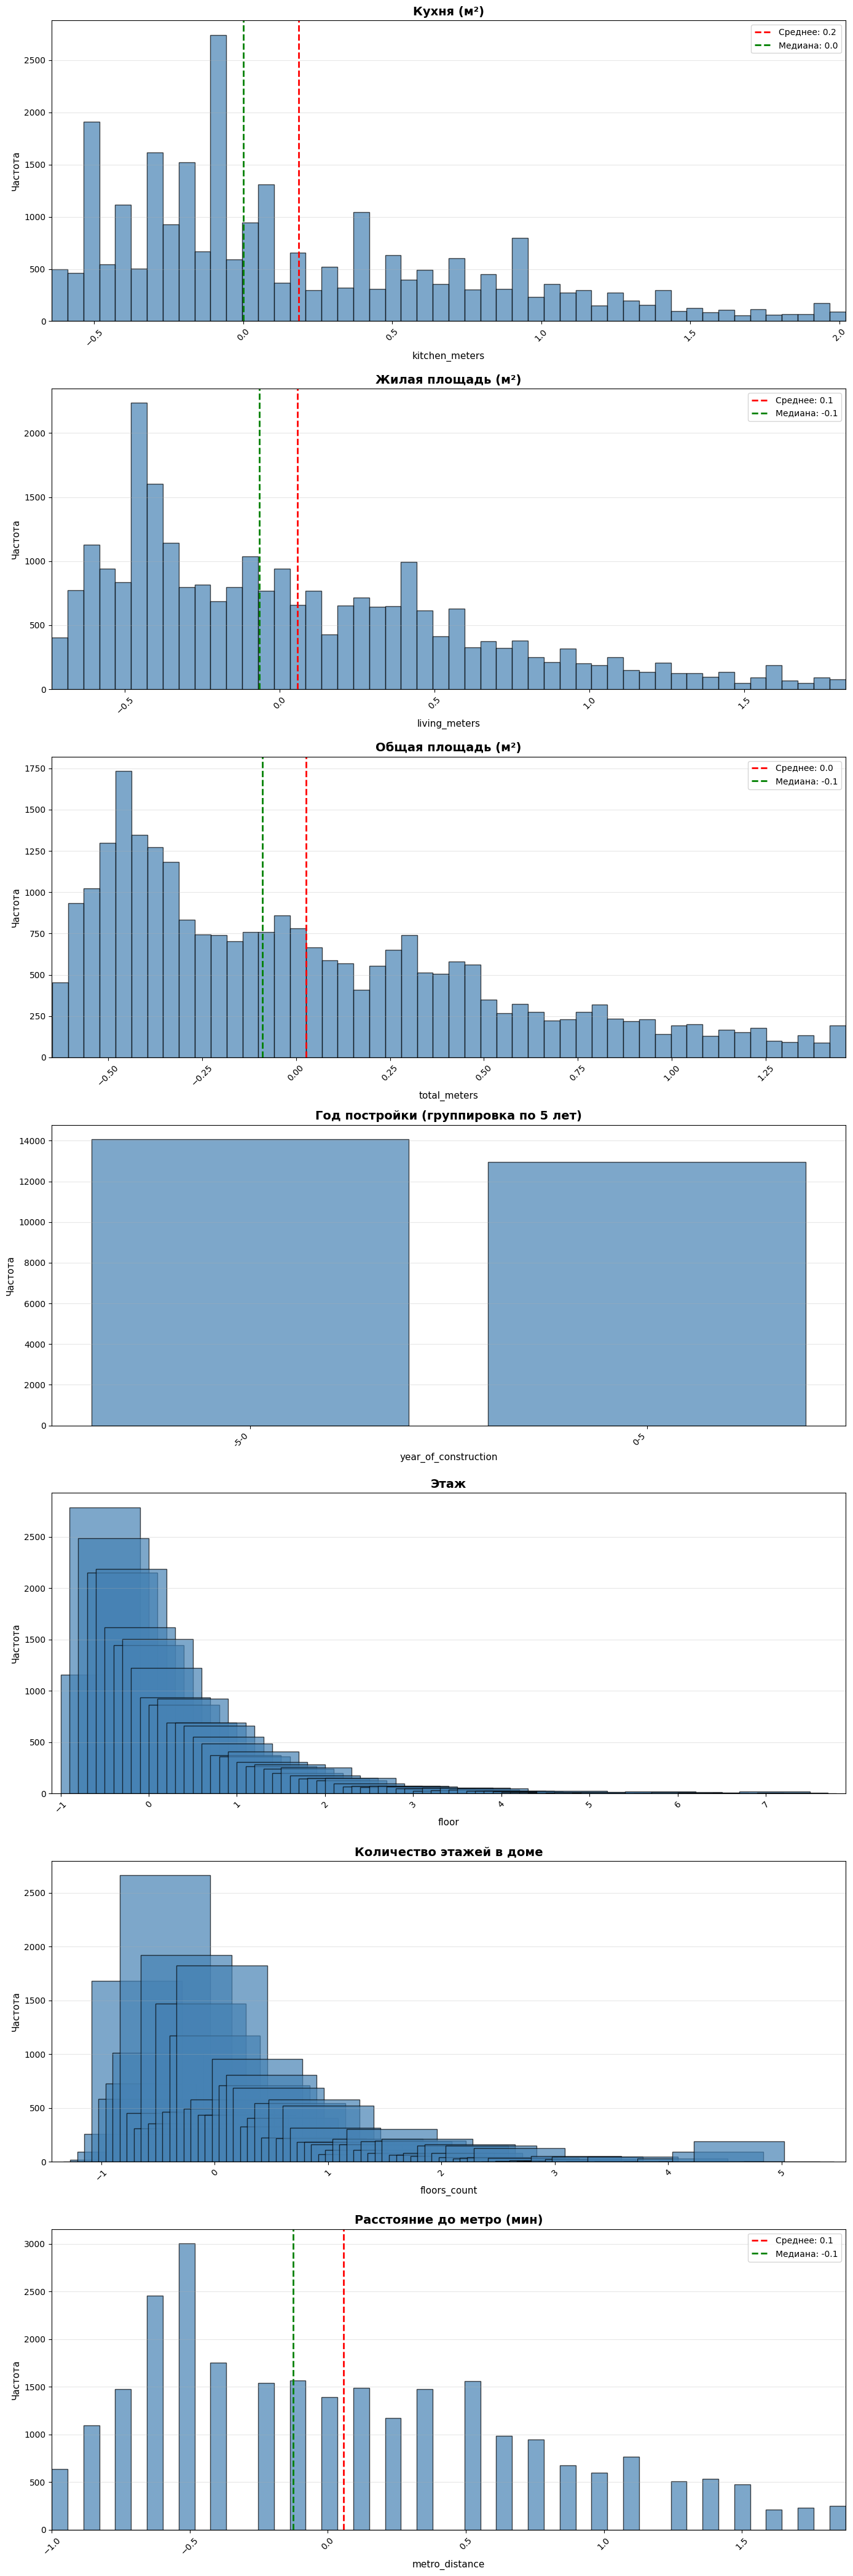

In [54]:
visual(X_train_imputed)


In [55]:


regressor = LinearRegression()
regressor.fit(X_train_imputed, y_train)

y_pred = regressor.predict(X_test_imputed)

score_r2 = r2_score(y_test, y_pred)
rmse_score = root_mean_squared_error(y_test, y_pred)
mae_score = mean_absolute_error(y_test, y_pred)
map_score = mean_absolute_percentage_error(y_test, y_pred)

print(f"map score = {map_score * 100}")
print(f"score_r2 = {score_r2}")
print(f"rmse score = {rmse_score}")
print(f"mae score = {mae_score}")

map score = 63.77875991164868
score_r2 = 0.5351064835862767
rmse score = 101995068.79850222
mae score = 33453798.243932996


In [56]:
regressor = DecisionTreeRegressor()
regressor.fit(X_train_imputed, y_train)

y_pred = regressor.predict(X_test_imputed)

score_r2 = r2_score(y_test, y_pred)
rmse_score = root_mean_squared_error(y_test, y_pred)
mae_score = mean_absolute_error(y_test, y_pred)
map_score = mean_absolute_percentage_error(y_test, y_pred)

print(f"map score = {map_score * 100}")
print(f"score_r2 = {score_r2}")
print(f"rmse score = {rmse_score}")
print(f"mae score = {mae_score}")

map score = 13.298811226809715
score_r2 = 0.44354095051086573
rmse score = 111588396.09448361
mae score = 21666488.193011615


In [57]:
regressor = KNeighborsRegressor()
regressor.fit(X_train_imputed, y_train)

y_pred = regressor.predict(X_test_imputed)

score_r2 = r2_score(y_test, y_pred)
rmse_score = root_mean_squared_error(y_test, y_pred)
mae_score = mean_absolute_error(y_test, y_pred)
map_score = mean_absolute_percentage_error(y_test, y_pred)

print(f"map score = {map_score * 100}")
print(f"score_r2 = {score_r2}")
print(f"rmse score = {rmse_score}")
print(f"mae score = {mae_score}")

map score = 16.47420774552838
score_r2 = 0.3847997810193614
rmse score = 117330432.413037
mae score = 24203264.939979415
